# Ncu Profiling Comparison
This notebook compares the results of ncu (Nsight Compute) reports of different SNP implementations.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Set plot style and increase font size for readability in slides
sns.set_theme(style="whitegrid")
sns.set_context("talk", 0.8) # Increases font scale for presentations
plt.rcParams['figure.figsize'] = [10, 5]

In [20]:
# Configuration
BASE_DIR = '../profiling/results/ncu'
TIMESTAMP = '20251217_083650' # Example timestamp
IMPLEMENTATIONS = ['sparse-cuda', 'optimized-cuda']

# Consistent Color Palette
COLOR_PALETTE = {
    'sparse-cuda': '#1f77b4',       # Blue
    'optimized-cuda': '#ff7f0e',    # Orange
    'naive-cuda-mpi-rb': '#2ca02c', # Green
    'naive-cpu': '#d62728'          # Red
}

In [21]:
def load_ncu_file(impl):
    """
    Loads the NCU CSV report for a given implementation.
    Handles unit parsing and normalization.
    """
    search_path = os.path.join(BASE_DIR, TIMESTAMP, impl, "snp_profile_metrics.csv")
    files = glob.glob(search_path)
    
    if not files:
        print(f"Warning: No file found for {impl} at {search_path}")
        return None
    
    file_path = files[0]
    try:
        # Read header and units
        # The CSV has header on line 0, units on line 1
        df_raw = pd.read_csv(file_path, header=0)
        
        # Extract units from the first row (which is index 0 now)
        units = df_raw.iloc[0]
        
        # Drop the units row and reset index
        df = df_raw.drop(0).reset_index(drop=True)
        
        # Convert numeric columns
        numeric_cols = [
            'dram__bytes_read.sum', 
            'dram__bytes_write.sum', 
            'gpu__time_duration.sum',
            'l1tex__data_bank_conflicts_pipe_lsu_mem_shared.sum',
            'lts__t_sectors_lookup_hit.sum',
            'lts__t_sectors_lookup_miss.sum'
        ]
        
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Normalize Duration to milliseconds (ms)
        duration_col = 'gpu__time_duration.sum'
        if duration_col in df.columns:
            unit = units[duration_col]
            if unit == 'usecond':
                df[duration_col] = df[duration_col] / 1000.0
            elif unit == 'msecond':
                pass # Already in ms
            elif unit == 'second':
                df[duration_col] = df[duration_col] * 1000.0
            # Add more conversions if needed
            
        df['Implementation'] = impl
        return df
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

def load_all_ncu_data():
    dfs = []
    for impl in IMPLEMENTATIONS:
        df = load_ncu_file(impl)
        if df is not None:
            dfs.append(df)
    
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

## Compare Kernel Execution Times
Comparing total execution time (ms) for kernels.
Note: Kernel names are cleaned (arguments removed).

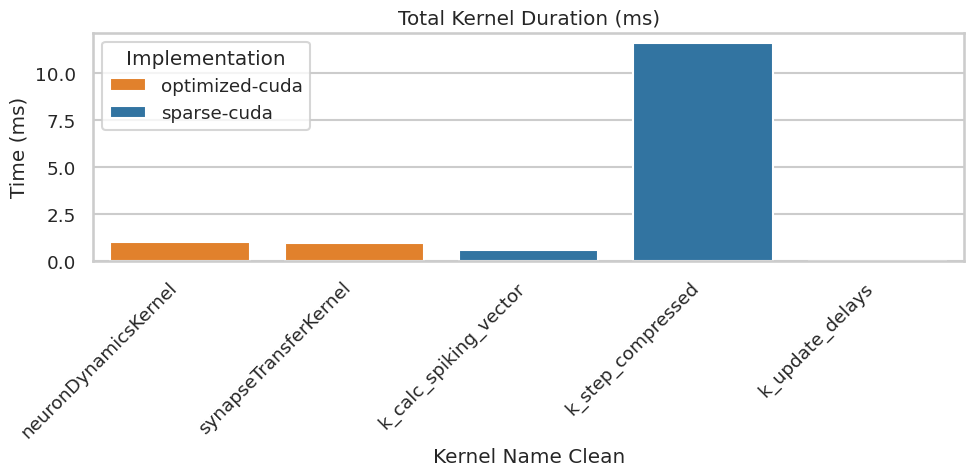

In [22]:
df = load_all_ncu_data()

if not df.empty:
    # Clean kernel names
    df['Kernel Name Clean'] = df['Kernel Name'].apply(lambda x: x.split('(')[0] if '(' in x else x)
    
    # Group by Implementation and Kernel Name
    df_grouped = df.groupby(['Implementation', 'Kernel Name Clean'])['gpu__time_duration.sum'].sum().reset_index()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_grouped, x='Kernel Name Clean', y='gpu__time_duration.sum', hue='Implementation', palette=COLOR_PALETTE)
    plt.title('Total Kernel Duration (ms)')
    plt.ylabel('Time (ms)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No data found.")

## Analyze Memory Bandwidth Utilization
Estimated Bandwidth = (Read + Write Bytes) / Duration.
Note: This is an effective bandwidth estimation based on DRAM traffic.

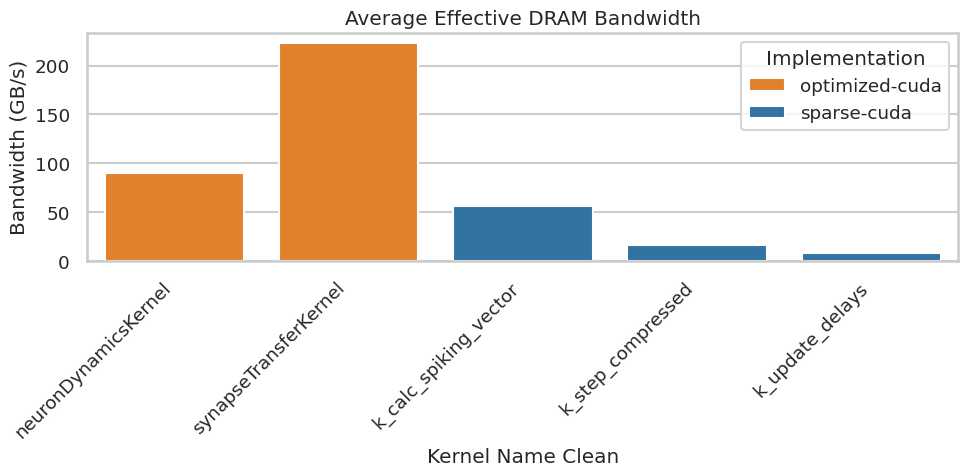

In [23]:
if not df.empty:
    # Calculate Bandwidth in GB/s
    # Bytes are in Mbyte (from CSV unit row usually, but let's assume Mbyte based on attachment)
    # Duration is in ms
    # GB/s = (Mbyte * 10^6) / (ms * 10^-3) / 10^9 = Mbyte / ms
    
    df['Total Bytes (MB)'] = df['dram__bytes_read.sum'] + df['dram__bytes_write.sum']
    df['Bandwidth (GB/s)'] = df['Total Bytes (MB)'] / df['gpu__time_duration.sum']
    
    # Average Bandwidth per Kernel Type
    df_bw = df.groupby(['Implementation', 'Kernel Name Clean'])['Bandwidth (GB/s)'].mean().reset_index()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_bw, x='Kernel Name Clean', y='Bandwidth (GB/s)', hue='Implementation', palette=COLOR_PALETTE)
    plt.title('Average Effective DRAM Bandwidth')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Analyze L2 Cache Hit Rates
Hit Rate = Hits / (Hits + Misses)

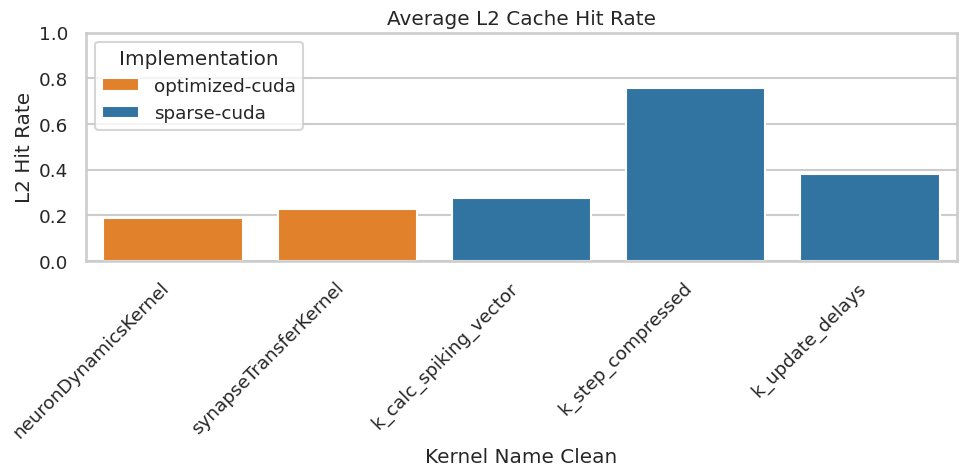

In [24]:
if not df.empty:
    df['L2 Hits'] = df['lts__t_sectors_lookup_hit.sum']
    df['L2 Misses'] = df['lts__t_sectors_lookup_miss.sum']
    df['L2 Hit Rate'] = df['L2 Hits'] / (df['L2 Hits'] + df['L2 Misses'])
    
    # Average Hit Rate per Kernel Type
    df_l2 = df.groupby(['Implementation', 'Kernel Name Clean'])['L2 Hit Rate'].mean().reset_index()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_l2, x='Kernel Name Clean', y='L2 Hit Rate', hue='Implementation', palette=COLOR_PALETTE)
    plt.title('Average L2 Cache Hit Rate')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()